In [36]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt  
import math
import seaborn as sns
from sklearn.linear_model import LinearRegression
from scipy import stats
%matplotlib inline

In [37]:
gs = pd.read_csv('C:\\Users\\91830\\OneDrive\\Desktop\\Data Analystics\\GOOG .csv')
gs.head(100)

,symbol,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
0,GOOG,2016-06-14 00:00:00+00:00,718.27,722.47,713.1200,716.48,1306065,718.27,722.47,713.1200,716.48,1306065,0.0,1.0
1,GOOG,2016-06-15 00:00:00+00:00,718.92,722.98,717.3100,719.00,1214517,718.92,722.98,717.3100,719.00,1214517,0.0,1.0
2,GOOG,2016-06-16 00:00:00+00:00,710.36,716.65,703.2600,714.91,1982471,710.36,716.65,703.2600,714.91,1982471,0.0,1.0
3,GOOG,2016-06-17 00:00:00+00:00,691.72,708.82,688.4515,708.65,3402357,691.72,708.82,688.4515,708.65,3402357,0.0,1.0
4,GOOG,2016-06-20 00:00:00+00:00,693.71,702.48,693.4100,698.77,2082538,693.71,702.48,693.4100,698.77,2082538,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,GOOG,2016-10-27 00:00:00+00:00,795.35,803.49,791.5000,801.00,2749221,795.35,803.49,791.5000,801.00,2749221,0.0,1.0
96,GOOG,2016-10-28 00:00:00+00:00,795.37,815.49,793.5900,808.35,4269902,795.37,815.49,793.5900,808.35,4269902,0.0,1.0
97,GOOG,2016-10-31 00:00:00+00:00,784.54,796.86,784.0000,795.47,2427284,784.54,796.86,784.0000,795.47,2427284,0.0,1.0
98,GOOG,2016-11-01 00:00:00+00:00,783.61,789.49,775.5400,782.89,2406356,783.61,789.49,775.5400,782.89,2406356,0.0,1.0


In [38]:
gs.describe(include='all')

,symbol,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
count,1258,1258,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03,1258.0,1258.0
unique,1,1258,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,GOOG,2016-06-14 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1258,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,1216.317067,1227.430934,1204.176430,1215.260779,1.601590e+06,1216.317067,1227.430936,1204.176436,1215.260779,1.601590e+06,0.0,1.0
std,NaN,NaN,383.333358,387.570872,378.777094,382.446995,6.960172e+05,383.333358,387.570873,378.777099,382.446995,6.960172e+05,0.0,0.0
min,NaN,NaN,668.260000,672.300000,663.284000,671.000000,3.467530e+05,668.260000,672.300000,663.284000,671.000000,3.467530e+05,0.0,1.0
25%,NaN,NaN,960.802500,968.757500,952.182500,959.005000,1.173522e+06,960.802500,968.757500,952.182500,959.005000,1.173522e+06,0.0,1.0
50%,NaN,NaN,1132.460000,1143.935000,1117.915000,1131.150000,1.412588e+06,1132.460000,1143.935000,1117.915000,1131.150000,1.412588e+06,0.0,1.0
75%,NaN,NaN,1360.595000,1374.345000,1348.557500,1361.075000,1.812156e+06,1360.595000,1374.345000,1348.557500,1361.075000,1.812156e+06,0.0,1.0


In [39]:
gs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   symbol       1258 non-null   object 
 1   date         1258 non-null   object 
 2   close        1258 non-null   float64
 3   high         1258 non-null   float64
 4   low          1258 non-null   float64
 5   open         1258 non-null   float64
 6   volume       1258 non-null   int64  
 7   adjClose     1258 non-null   float64
 8   adjHigh      1258 non-null   float64
 9   adjLow       1258 non-null   float64
 10  adjOpen      1258 non-null   float64
 11  adjVolume    1258 non-null   int64  
 12  divCash      1258 non-null   float64
 13  splitFactor  1258 non-null   float64
dtypes: float64(10), int64(2), object(2)
memory usage: 137.7+ KB


In [40]:
#Data Wrangling

data1= gs.dropna(subset=['high'], axis=0 ,inplace=True)
data1

In [41]:
#Normalizing Data
gs['close']=(gs['close']/gs['close'].min())/(gs['close'].max()-gs['close'].min())
gs['close']

0       0.000580
1       0.000580
2       0.000574
3       0.000559
4       0.000560
          ...   
1253    0.001991
1254    0.002005
1255    0.002012
1256    0.002036
1257    0.002030
Name: close, Length: 1258, dtype: float64

In [42]:
#Z-score

gs['high']=(gs['high']- gs['high'].mean())/gs['high'].std()
gs['high']

0      -1.302887
1      -1.301571
2      -1.317903
3      -1.338106
4      -1.354464
          ...   
1253    3.200883
1254    3.269245
1255    3.296350
1256    3.343464
1257    3.353088
Name: high, Length: 1258, dtype: float64

In [43]:
#Binning in PY Pandas

bin = np.linspace(min(gs['close']),max(gs['high']),4)
group_name=['Low','Medium','High']
gs['google_binned']=pd.cut(gs['close'],bin, labels=group_name, include_lowest=True)

gs['google_binned']

0       Low
1       Low
2       Low
3       Low
4       Low
       ... 
1253    Low
1254    Low
1255    Low
1256    Low
1257    Low
Name: google_binned, Length: 1258, dtype: category
Categories (3, object): ['Low' < 'Medium' < 'High']

In [44]:
pd.get_dummies(gs['high'])

,-1.432334,-1.411615,-1.393298,-1.388213,-1.380679,-1.368759,-1.365508,-1.359186,-1.358644,-1.356529,...,3.128638,3.133799,3.136234,3.160576,3.164397,3.200883,3.269245,3.296350,3.343464,3.353088
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1253,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
1254,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1255,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1256,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False


Text(0.5, 1.0, 'Stock Bins')

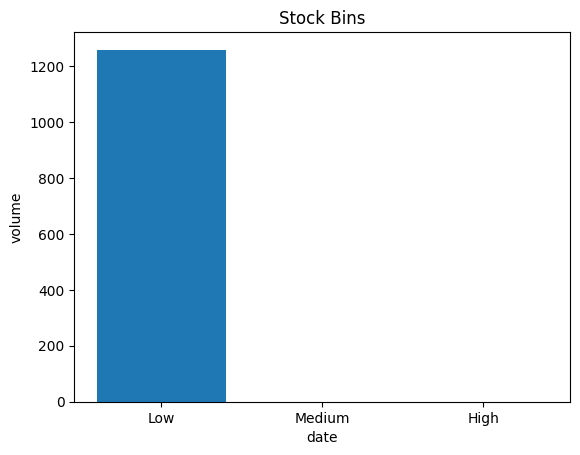

In [45]:
plt.bar(group_name, gs['google_binned'].value_counts())
plt.xlabel('date')
plt.ylabel('volume')
plt.title('Stock Bins')

In [46]:
#Correlation

gs[['adjClose','adjHigh','adjLow','adjOpen','adjVolume','divCash',	'splitFactor']].corr()

,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
adjClose,1.000000,0.999528,0.999586,0.999083,-0.025574,NaN,NaN
adjHigh,0.999528,1.000000,0.999354,0.999575,-0.012470,NaN,NaN
adjLow,0.999586,0.999354,1.000000,0.999499,-0.035184,NaN,NaN
adjOpen,0.999083,0.999575,0.999499,1.000000,-0.021381,NaN,NaN
adjVolume,-0.025574,-0.012470,-0.035184,-0.021381,1.000000,NaN,NaN
divCash,NaN,NaN,NaN,NaN,NaN,NaN,NaN
splitFactor,NaN,NaN,NaN,NaN,NaN,NaN,NaN


(10.9, 6500040.7)

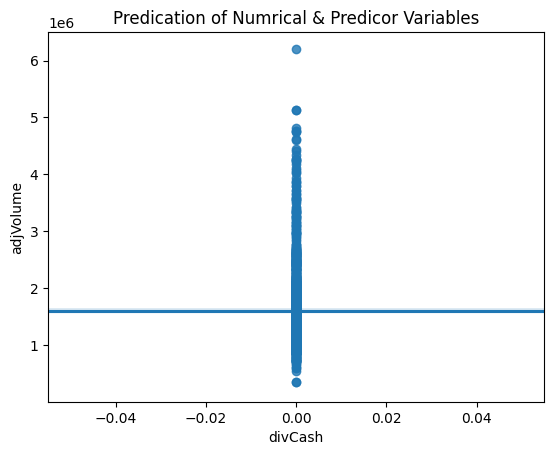

In [47]:
#Continuous Numercal Variables--- Predictor variable

sns.regplot(y='adjVolume',x='divCash',data=gs)
plt.title('Predication of Numrical & Predicor Variables')
plt.ylim(10.9)


(0.0, 3.9327700330709)

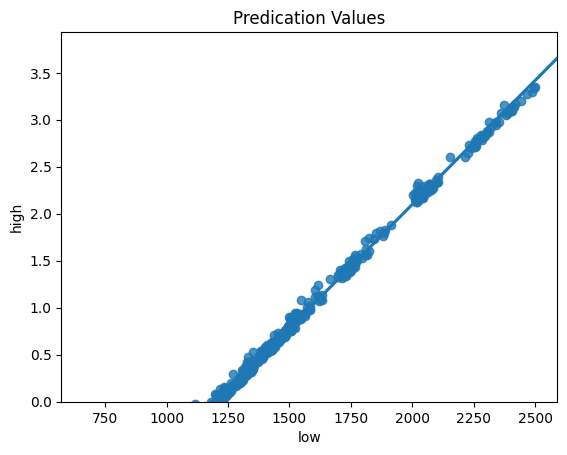

In [48]:
sns.regplot(y='high',x='low',data=gs)
plt.title('Predication Values')
plt.ylim(0,)

(10.9, 6500040.7)

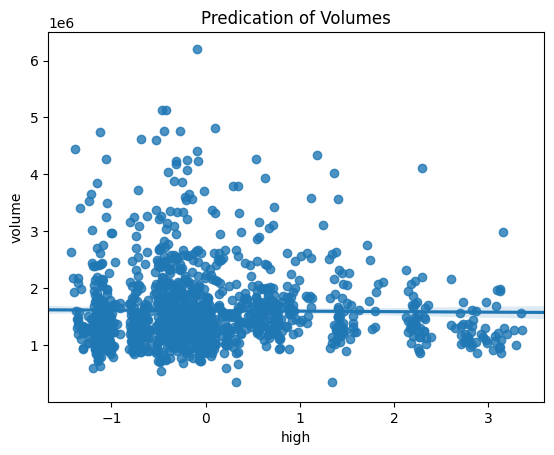

In [49]:
sns.regplot(y='volume',x='high',data=gs)
plt.title('Predication of Volumes')
plt.ylim(10.9)

In [50]:
gs.head(3)

,symbol,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor,google_binned
0,GOOG,2016-06-14 00:00:00+00:00,0.000580,-1.302887,713.12,716.48,1306065,718.27,722.47,713.12,716.48,1306065,0.0,1.0,Low
1,GOOG,2016-06-15 00:00:00+00:00,0.000580,-1.301571,717.31,719.00,1214517,718.92,722.98,717.31,719.00,1214517,0.0,1.0,Low
2,GOOG,2016-06-16 00:00:00+00:00,0.000574,-1.317903,703.26,714.91,1982471,710.36,716.65,703.26,714.91,1982471,0.0,1.0,Low


In [51]:
gs[['close','high','low','volume']].corr()

,close,high,low,volume
close,1.000000,0.999528,0.999586,-0.025574
high,0.999528,1.000000,0.999354,-0.012470
low,0.999586,0.999354,1.000000,-0.035184
volume,-0.025574,-0.012470,-0.035184,1.000000


In [52]:
num=gs.select_dtypes(include=['int64','float64'])
num

,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
0,0.000580,-1.302887,713.1200,716.48,1306065,718.27,722.470,713.1200,716.48,1306065,0.0,1.0
1,0.000580,-1.301571,717.3100,719.00,1214517,718.92,722.980,717.3100,719.00,1214517,0.0,1.0
2,0.000574,-1.317903,703.2600,714.91,1982471,710.36,716.650,703.2600,714.91,1982471,0.0,1.0
3,0.000559,-1.338106,688.4515,708.65,3402357,691.72,708.820,688.4515,708.65,3402357,0.0,1.0
4,0.000560,-1.354464,693.4100,698.77,2082538,693.71,702.480,693.4100,698.77,2082538,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1253,0.001991,3.200883,2441.0725,2451.32,1192453,2466.09,2468.000,2441.0725,2451.32,1192453,0.0,1.0
1254,0.002005,3.269245,2468.2400,2479.90,1253253,2482.85,2494.495,2468.2400,2479.90,1253253,0.0,1.0
1255,0.002012,3.296350,2487.3300,2499.50,1006337,2491.40,2505.000,2487.3300,2499.50,1006337,0.0,1.0
1256,0.002036,3.343464,2494.0000,2494.01,1561733,2521.60,2523.260,2494.0000,2494.01,1561733,0.0,1.0


In [53]:
num.describe()

,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
count,1258.000000,1.258000e+03,1258.000000,1258.000000,1.258000e+03,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03,1258.0,1258.0
mean,0.000982,-2.259277e-16,1204.176430,1215.260779,1.601590e+06,1216.317067,1227.430936,1204.176436,1215.260779,1.601590e+06,0.0,1.0
std,0.000310,1.000000e+00,378.777094,382.446995,6.960172e+05,383.333358,387.570873,378.777099,382.446995,6.960172e+05,0.0,0.0
min,0.000540,-1.432334e+00,663.284000,671.000000,3.467530e+05,668.260000,672.300000,663.284000,671.000000,3.467530e+05,0.0,1.0
25%,0.000776,-6.674223e-01,952.182500,959.005000,1.173522e+06,960.802500,968.757500,952.182500,959.005000,1.173522e+06,0.0,1.0
50%,0.000914,-2.154340e-01,1117.915000,1131.150000,1.412588e+06,1132.460000,1143.935000,1117.915000,1131.150000,1.412588e+06,0.0,1.0
75%,0.001099,3.790637e-01,1348.557500,1361.075000,1.812156e+06,1360.595000,1374.345000,1348.557500,1361.075000,1.812156e+06,0.0,1.0
max,0.002036,3.353088e+00,2498.290000,2524.920000,6.207027e+06,2521.600000,2526.990000,2498.290000,2524.920000,6.207027e+06,0.0,1.0


In [54]:
Gs=gs['volume'].to_frame()
Gs

,volume
0,1306065
1,1214517
2,1982471
3,3402357
4,2082538
...,...
1253,1192453
1254,1253253
1255,1006337
1256,1561733


In [55]:
GS=gs['low'].unique()
GS

array([ 713.12,  717.31,  703.26, ..., 2487.33, 2494.  , 2498.29])

In [56]:
#Grouping 
gs_group=num.groupby(['close'], as_index=False).agg({'volume':'mean'})
gs_group

,close,volume
0,0.000540,2641085.0
1,0.000545,4449022.0
2,0.000549,2173762.0
3,0.000552,1932561.0
4,0.000559,3402357.0
...,...,...
1242,0.001991,1192453.0
1243,0.002005,1253253.0
1244,0.002012,1006337.0
1245,0.002030,1262309.0


In [57]:
#Gruoping and Descriptive statistics
gs_groups=num.groupby(['close'], as_index=False).agg({'volume':'mean','high':'median','splitFactor':'mean'})
gs_groups

,close,volume,high,splitFactor
0,0.000540,2641085.0,-1.432334,1.0
1,0.000545,4449022.0,-1.388213,1.0
2,0.000549,2173762.0,-1.411615,1.0
3,0.000552,1932561.0,-1.393298,1.0
4,0.000559,3402357.0,-1.338106,1.0
...,...,...,...,...
1242,0.001991,1192453.0,3.200883,1.0
1243,0.002005,1253253.0,3.269245,1.0
1244,0.002012,1006337.0,3.296350,1.0
1245,0.002030,1262309.0,3.353088,1.0


Text(0.5, 1.0, 'taget of Volume')

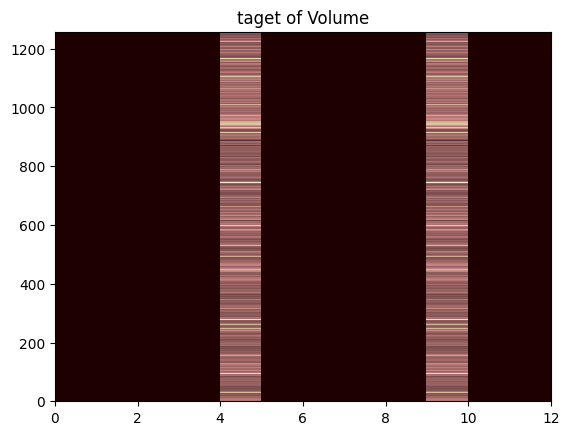

In [71]:
#The heatmap plots the target variable

figs, ax= plt.subplots()
Im=ax.pcolor(num,cmap='pink')
plt.title('taget of Volume')

In [59]:
#create the group

test= gs[['close','volume','high','low']]

In [60]:
groups=test.groupby(['close','volume','high','low'], as_index=False).mean()
groups

,close,volume,high,low
0,0.000540,2641085,-1.432334,663.2840
1,0.000545,4449022,-1.388213,673.4500
2,0.000549,2173762,-1.411615,673.0000
3,0.000552,1932561,-1.393298,681.4100
4,0.000559,3402357,-1.338106,688.4515
...,...,...,...,...
1253,0.001991,1192453,3.200883,2441.0725
1254,0.002005,1253253,3.269245,2468.2400
1255,0.002012,1006337,3.296350,2487.3300
1256,0.002030,1262309,3.353088,2498.2900


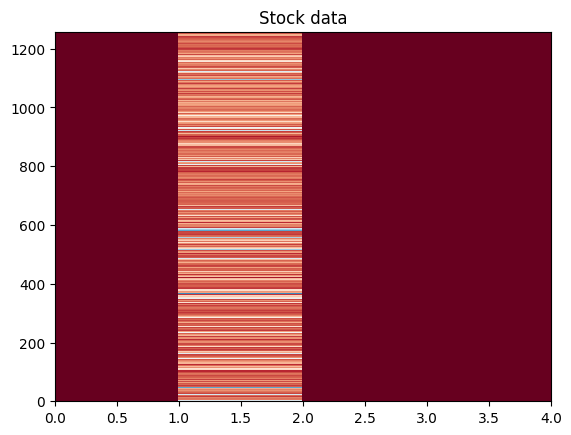

In [72]:
plt.pcolor(groups,cmap='RdBu')
plt.title('Stock data')
plt.show()

In [62]:
groups_pivot=groups.pivot(index='close',columns='low')
groups_pivot


volume                                                       \
low       663.2840   673.0000   673.4500   681.4100  683.6500  687.0000    
close                                                                      
0.000540  2641085.0        NaN        NaN        NaN       NaN       NaN   
0.000545        NaN        NaN  4449022.0        NaN       NaN       NaN   
0.000549        NaN  2173762.0        NaN        NaN       NaN       NaN   
0.000552        NaN        NaN        NaN  1932561.0       NaN       NaN   
0.000559        NaN        NaN        NaN        NaN       NaN       NaN   
...             ...        ...        ...        ...       ...       ...   
0.001991        NaN        NaN        NaN        NaN       NaN       NaN   
0.002005        NaN        NaN        NaN        NaN       NaN       NaN   
0.002012        NaN        NaN        NaN        NaN       NaN       NaN   
0.002030        NaN        NaN        NaN        NaN       NaN       NaN   
0.002036        NaN        NaN        NaN        NaN       NaN       NaN   

                                                   ...      high            \
low      688.2150   688.4515  688.8800  689.0900   ... 2404.2000 2404.8800   
close                                              ...                       
0.000540       NaN        NaN       NaN       NaN  ...       NaN       NaN   
0.000545       NaN        NaN       NaN       NaN  ...       NaN       NaN   
0.000549       NaN        NaN       NaN       NaN  ...       NaN       NaN   
0.000552       NaN        NaN       NaN       NaN  ...       NaN       NaN   
0.000559       NaN  3402357.0       NaN       NaN  ...       NaN       NaN   
...            ...        ...       ...       ...  ...       ...       ...   
0.001991       NaN        NaN       NaN       NaN  ...       NaN       NaN   
0.002005       NaN        NaN       NaN       NaN  ...       NaN       NaN   
0.002012       NaN        NaN       NaN       NaN  ...       NaN       NaN   
0.002030       NaN        NaN       NaN       NaN  ...       NaN       NaN   
0.002036       NaN        NaN       NaN       NaN  ...       NaN       NaN   

                                                                      \
low      2407.6900 2412.5150 2417.7700 2441.0725 2468.2400 2487.3300   
close                                                                  
0.000540       NaN       NaN       NaN       NaN       NaN       NaN   
0.000545       NaN       NaN       NaN       NaN       NaN       NaN   
0.000549       NaN       NaN       NaN       NaN       NaN       NaN   
0.000552       NaN       NaN       NaN       NaN       NaN       NaN   
0.000559       NaN       NaN       NaN       NaN       NaN       NaN   
...            ...       ...       ...       ...       ...       ...   
0.001991       NaN       NaN       NaN  3.200883       NaN       NaN   
0.002005       NaN       NaN       NaN       NaN  3.269245       NaN   
0.002012       NaN       NaN       NaN       NaN       NaN   3.29635   
0.002030       NaN       NaN       NaN       NaN       NaN       NaN   
0.002036       NaN       NaN       NaN       NaN       NaN       NaN   

                              
low      2494.0000 2498.2900  
close                         
0.000540       NaN       NaN  
0.000545       NaN       NaN  
0.000549       NaN       NaN  
0.000552       NaN       NaN  
0.000559       NaN       NaN  
...            ...       ...  
0.001991       NaN       NaN  
0.002005       NaN       NaN  
0.002012       NaN       NaN  
0.002030       NaN  3.353088  
0.002036  3.343464       NaN  

[1247 rows x 2488 columns]

Text(0.5, 1.0, 'Low to High Variables')

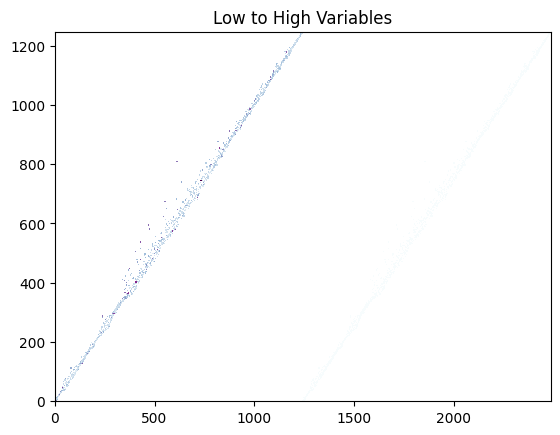

In [73]:
fig ,ax = plt.subplots()
im = ax.pcolor(groups_pivot,cmap='BuPu')

plt.title('Low to High Variables')

In [64]:
row_labels = groups_pivot.columns.levels[1]
col_labels = groups_pivot.index

In [65]:
#move ticks and labels to the center and insert labels

ax.set_xticks(np.arange(groups_pivot.shape[1])+ 0.5, minor=False)
ax.set_yticks(np.arange(groups_pivot.shape[0])+ 0.5, minor=False)


 ...]

In [66]:
#Correlation Values of the three Attributs

for params in['high','low','volume']:
    print(f"correlation of Stock and {params}",gs[[params,'adjHigh']].corr())

correlation of Stock and high          high  adjHigh
high      1.0      1.0
adjHigh   1.0      1.0
correlation of Stock and low               low   adjHigh
low      1.000000  0.999354
adjHigh  0.999354  1.000000
correlation of Stock and volume           volume  adjHigh
volume   1.00000 -0.01247
adjHigh -0.01247  1.00000


In [67]:
for param in ['close','high','low','volume']:
    pearson_coef, P_value = stats.pearsonr(groups[param],groups['volume'])
    print("The pearson correlation corfficient for", param,'is',pearson_coef,"with a P_value=", P_value)

The pearson correlation corfficient for close is -0.025573803078510114 with a P_value= 0.36477405345800307
The pearson correlation corfficient for high is -0.012470251835490597 with a P_value= 0.6585788856066495
The pearson correlation corfficient for low is -0.0351837063055531 with a P_value= 0.21237855757793866
The pearson correlation corfficient for volume is 0.9999999999999998 with a P_value= 0.0


End of the Project
